In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(df.shape)
print(df.dtypes)

(1460, 81)
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


In [4]:
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
print(missing)
print(f"/nTotal columns with missing values: {len(missing)}")

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64
/nTotal columns with missing values: 19


In [5]:
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", 
             "FireplaceQu", "GarageType", "GarageFinish",
             "GarageQual", "GarageCond", "BsmtQual", "BsmtCond",
             "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]

for col in none_cols:
    df[col] = df[col].fillna("None")
zero_cols = ["GarageYrBlt", "MasVnrArea"]
for col in zero_cols:
    df[col] = df[col].fillna(0)
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)
df = df.dropna(subset=["Electrical"])
print(df.isnull().sum().sum())

0


In [6]:
print(df["SalePrice"].describe())

count      1459.000000
mean     180930.394791
std       79468.964025
min       34900.000000
25%      129950.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


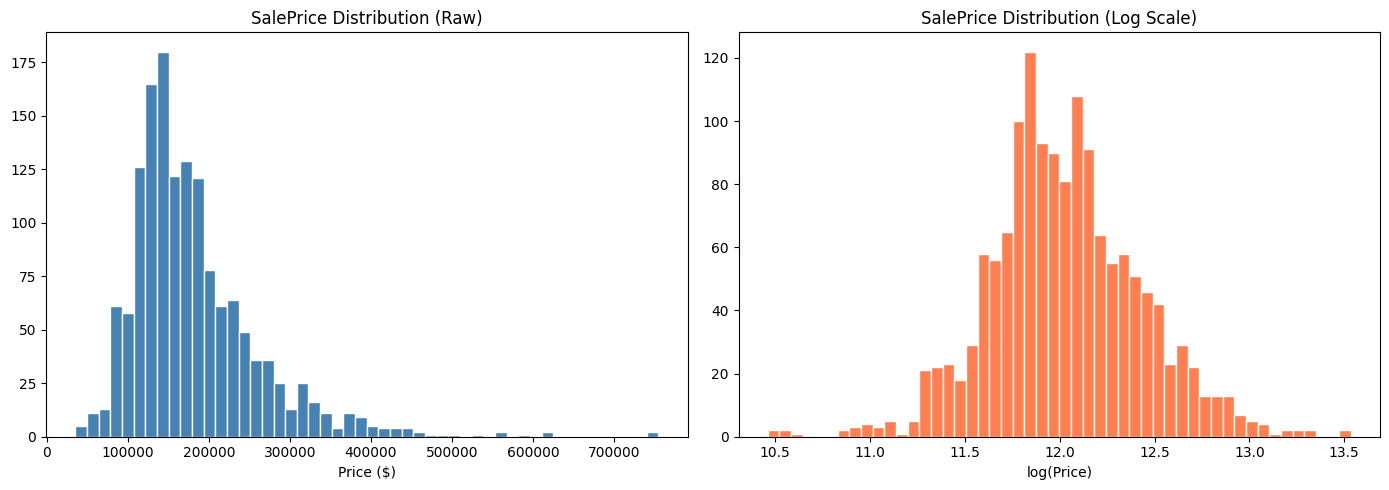

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["SalePrice"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("SalePrice Distribution (Raw)")
axes[0].set_xlabel("Price ($)")

axes[1].hist(np.log1p(df["SalePrice"]), bins=50, color="coral", edgecolor="white")
axes[1].set_title("SalePrice Distribution (Log Scale)")
axes[1].set_xlabel("log(Price)")

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats
print(f"Skewness: {df['SalePrice'].skew():.4f}")

Skewness: 1.8819


Skewness after log transform: 0.1213


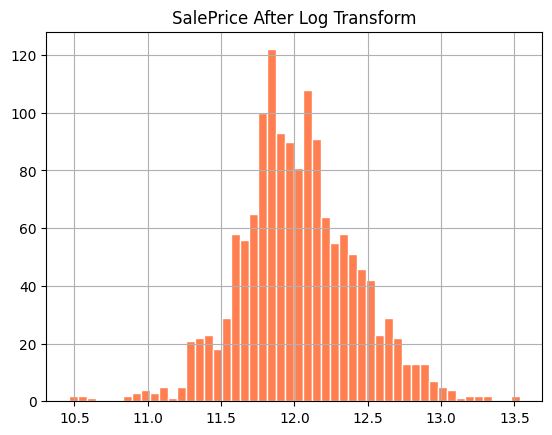

In [9]:
y = np.log1p(df["SalePrice"])

# Verify skewness is now close to 0
print(f"Skewness after log transform: {y.skew():.4f}")

# Plot to confirm
y.hist(bins=50, color="coral", edgecolor="white")
plt.title("SalePrice After Log Transform")
plt.show()

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()["SalePrice"].sort_values(ascending=False)
print(correlation.head(15))

SalePrice       1.000000
OverallQual     0.791069
GrLivArea       0.708618
GarageCars      0.640473
GarageArea      0.623423
TotalBsmtSF     0.613905
1stFlrSF        0.605968
FullBath        0.560881
TotRmsAbvGrd    0.533779
YearBuilt       0.523273
YearRemodAdd    0.507430
MasVnrArea      0.472606
Fireplaces      0.466968
BsmtFinSF1      0.386436
LotFrontage     0.349895
Name: SalePrice, dtype: float64


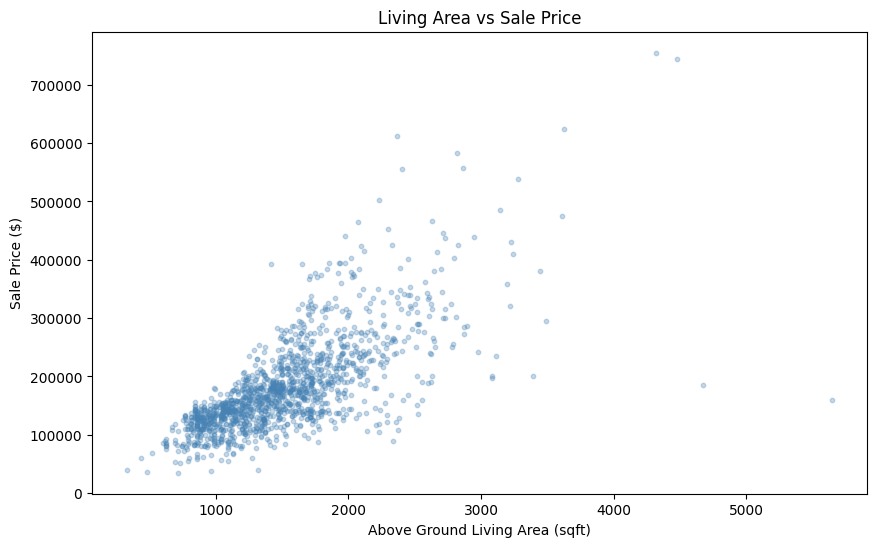

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df["GrLivArea"], df["SalePrice"], 
            alpha=0.3, s=10, color="steelblue")
plt.xlabel("Above Ground Living Area (sqft)")
plt.ylabel("Sale Price ($)")
plt.title("Living Area vs Sale Price")
plt.show()

Rows remaining: 1457


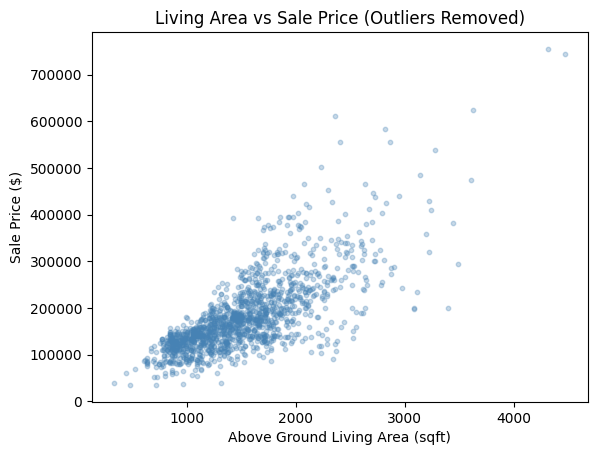

In [12]:
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000))]
print(f"Rows remaining: {len(df)}")

plt.scatter(df["GrLivArea"], df["SalePrice"], 
            alpha=0.3, s=10, color="steelblue")
plt.xlabel("Above Ground Living Area (sqft)")
plt.ylabel("Sale Price ($)")
plt.title("Living Area vs Sale Price (Outliers Removed)")
plt.show()

In [13]:
numeric = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns:     {len(numeric)}")
print(f"Categorical columns: {len(categorical)}")
print(f"\nCategorical columns:\n{categorical}")

Numeric columns:     38
Categorical columns: 43

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [14]:
for col in categorical:
    print(f"{col}: {df[col].nunique()} unique values")

MSZoning: 5 unique values
Street: 2 unique values
Alley: 3 unique values
LotShape: 4 unique values
LandContour: 4 unique values
Utilities: 2 unique values
LotConfig: 5 unique values
LandSlope: 3 unique values
Neighborhood: 25 unique values
Condition1: 9 unique values
Condition2: 8 unique values
BldgType: 5 unique values
HouseStyle: 8 unique values
RoofStyle: 6 unique values
RoofMatl: 7 unique values
Exterior1st: 15 unique values
Exterior2nd: 16 unique values
MasVnrType: 4 unique values
ExterQual: 4 unique values
ExterCond: 5 unique values
Foundation: 6 unique values
BsmtQual: 5 unique values
BsmtCond: 5 unique values
BsmtExposure: 5 unique values
BsmtFinType1: 7 unique values
BsmtFinType2: 7 unique values
Heating: 6 unique values
HeatingQC: 5 unique values
CentralAir: 2 unique values
Electrical: 5 unique values
KitchenQual: 4 unique values
Functional: 7 unique values
FireplaceQu: 6 unique values
GarageType: 7 unique values
GarageFinish: 4 unique values
GarageQual: 6 unique values
Garag

In [15]:
print(df["Utilities"].value_counts())
print(df["Street"].value_counts())

Utilities
AllPub    1456
NoSeWa       1
Name: count, dtype: int64
Street
Pave    1451
Grvl       6
Name: count, dtype: int64


In [20]:
quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

ordinal_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
                "HeatingQC", "KitchenQual", "FireplaceQu",
                "GarageQual", "GarageCond", "PoolQC"]

for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

print("Ordinal encoding done ✓")
print(df[ordinal_cols].head())

Ordinal encoding done ✓
   ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
0          4          3         4         3          5            4   
1          3          3         4         3          5            3   
2          4          3         4         3          5            4   
3          3          3         3         4          4            4   
4          4          3         4         3          5            4   

   FireplaceQu  GarageQual  GarageCond  PoolQC  
0            0           3           3       0  
1            3           3           3       0  
2            3           3           3       0  
3            4           3           3       0  
4            3           3           3       0  


In [19]:
print(df.columns.tolist())

['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscFeature', 'Mi

In [21]:
from sklearn.model_selection import train_test_split

y = np.log1p(df["SalePrice"])
X = df.drop(columns=["SalePrice"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_df = X_train.copy()
train_df["SalePrice"] = np.expm1(y_train)

high_cardinality = ["Neighborhood", "Exterior1st", "Exterior2nd"]

for col in high_cardinality:
    encoding = train_df.groupby(col)["SalePrice"].mean()
    X_train[col] = X_train[col].map(encoding)
    X_test[col]  = X_test[col].map(encoding)
    global_mean = train_df["SalePrice"].mean()
    X_train[col] = X_train[col].fillna(global_mean)
    X_test[col]  = X_test[col].fillna(global_mean)

print("Target encoding done ✓")

Target encoding done ✓


In [22]:
categorical_remaining = X_train.select_dtypes(include=["object"]).columns.tolist()
print(f"Remaining categorical columns: {len(categorical_remaining)}")
print(categorical_remaining)

Remaining categorical columns: 28
['MSZoning', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [23]:
X_train = pd.get_dummies(X_train, 
    columns=categorical_remaining, 
    drop_first=True)

X_test = pd.get_dummies(X_test, 
    columns=categorical_remaining, 
    drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

Train shape: (1165, 172)
Test shape:  (292, 172)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2  = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lr))

print(f"R²:                  {r2:.4f}")
print(f"MAE (log):           {mae:.4f}")
print(f"Average price error: ${mae_dollars:,.0f}")

R²:                  0.8339
MAE (log):           0.1410
Average price error: $24,228


In [30]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

r2  = r2_score(y_test, y_pred_xgb)
mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb))

print(f"R²:                  {r2:.4f}")
print(f"Average price error: ${mae_dollars:,.0f}")

R²:                  0.8884
Average price error: $15,737


In [31]:
# Total square footage — combining all area features
X_train["TotalSF"] = (X_train["TotalBsmtSF"] + 
                      X_train["1stFlrSF"] + 
                      X_train["2ndFlrSF"])

X_test["TotalSF"]  = (X_test["TotalBsmtSF"] + 
                      X_test["1stFlrSF"] + 
                      X_test["2ndFlrSF"])

# Total bathrooms
X_train["TotalBath"] = (X_train["FullBath"] + 
                        X_train["BsmtFullBath"] +
                        0.5 * X_train["HalfBath"] + 
                        0.5 * X_train["BsmtHalfBath"])

X_test["TotalBath"]  = (X_test["FullBath"] + 
                        X_test["BsmtFullBath"] +
                        0.5 * X_test["HalfBath"] + 
                        0.5 * X_test["BsmtHalfBath"])

# House age at time of sale
X_train["HouseAge"] = X_train["YrSold"] - X_train["YearBuilt"]
X_test["HouseAge"]  = X_test["YrSold"]  - X_test["YearBuilt"]

# Was the house remodelled?
X_train["IsRemodeled"] = (X_train["YearRemodAdd"] != X_train["YearBuilt"]).astype(int)
X_test["IsRemodeled"]  = (X_test["YearRemodAdd"]  != X_test["YearBuilt"]).astype(int)

print("New features created ✓")
print(f"New shape: {X_train.shape}")

New features created ✓
New shape: (1165, 176)


In [33]:
X_train["QualArea"] = X_train["OverallQual"] * X_train["GrLivArea"]
X_test["QualArea"]  = X_test["OverallQual"]  * X_test["GrLivArea"]

X_train["QualSquared"] = X_train["OverallQual"] ** 2
X_test["QualSquared"]  = X_test["OverallQual"]  ** 2

X_train["HasGarage"] = (X_train["GarageArea"] > 0).astype(int)
X_test["HasGarage"]  = (X_test["GarageArea"]  > 0).astype(int)

X_train["HasBasement"] = (X_train["TotalBsmtSF"] > 0).astype(int)
X_test["HasBasement"]  = (X_test["TotalBsmtSF"]  > 0).astype(int)

print(f"Shape: {X_train.shape}")

Shape: (1165, 180)


In [35]:
cols_to_drop = ["QualArea", "QualSquared", "HasGarage", "HasBasement"]

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print(f"Shape: {X_train.shape}")

Shape: (1165, 176)


In [37]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "max_depth":        [3, 4, 5, 6, 8],
    "n_estimators":     [500, 1000, 1500],
    "subsample":        [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,              
    cv=5,
    scoring="neg_mean_absolute_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print(f"Best params: {random_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.6, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [43]:
final_model = XGBRegressor(
    learning_rate=0.01,
    max_depth=4,
    n_estimators=2500,
    subsample=0.6,
    colsample_bytree=0.7,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

r2  = r2_score(y_test, y_pred_final)
mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_final))

print(f"R²:                  {r2:.4f}")
print(f"Average price error: ${mae_dollars:,.0f}")

R²:                  0.9131
Average price error: $14,018


In [39]:
test_kaggle = pd.read_csv("test.csv")
print(test_kaggle.shape)

(1459, 80)


In [40]:
# Step 1 — Fix missing values
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence",
             "FireplaceQu", "GarageType", "GarageFinish",
             "GarageQual", "GarageCond", "BsmtQual", "BsmtCond",
             "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]

for col in none_cols:
    test_kaggle[col] = test_kaggle[col].fillna("None")

zero_cols = ["GarageYrBlt", "MasVnrArea"]
for col in zero_cols:
    test_kaggle[col] = test_kaggle[col].fillna(0)

# Fill numeric with median
numeric_cols = test_kaggle.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    test_kaggle[col] = test_kaggle[col].fillna(test_kaggle[col].median())

# Fill remaining categorical with most frequent value
cat_cols = test_kaggle.select_dtypes(include=["object"]).columns
for col in cat_cols:
    test_kaggle[col] = test_kaggle[col].fillna(test_kaggle[col].mode()[0])

print(f"Missing values: {test_kaggle.isnull().sum().sum()}")

Missing values: 0


In [41]:
# Save Id for submission file
test_ids = test_kaggle["Id"]

# Drop useless columns
test_kaggle = test_kaggle.drop(columns=["Id", "Utilities", "Street"], errors="ignore")

# Ordinal encode quality columns
quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ordinal_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
                "HeatingQC", "KitchenQual", "FireplaceQu",
                "GarageQual", "GarageCond", "PoolQC"]

for col in ordinal_cols:
    test_kaggle[col] = test_kaggle[col].map(quality_map)

# Target encode high cardinality columns
high_cardinality = ["Neighborhood", "Exterior1st", "Exterior2nd"]
for col in high_cardinality:
    test_kaggle[col] = test_kaggle[col].map(
        train_df.groupby(col)["SalePrice"].mean()
    )
    test_kaggle[col] = test_kaggle[col].fillna(train_df["SalePrice"].mean())

# New features
test_kaggle["TotalSF"]    = (test_kaggle["TotalBsmtSF"] + 
                             test_kaggle["1stFlrSF"] + 
                             test_kaggle["2ndFlrSF"])
test_kaggle["TotalBath"]  = (test_kaggle["FullBath"] + 
                             test_kaggle["BsmtFullBath"] +
                             0.5 * test_kaggle["HalfBath"] + 
                             0.5 * test_kaggle["BsmtHalfBath"])
test_kaggle["HouseAge"]   = test_kaggle["YrSold"] - test_kaggle["YearBuilt"]
test_kaggle["IsRemodeled"] = (test_kaggle["YearRemodAdd"] != test_kaggle["YearBuilt"]).astype(int)

# One-hot encode
test_kaggle = pd.get_dummies(test_kaggle, drop_first=True)

# Align with training columns
test_kaggle = test_kaggle.reindex(columns=X_train.columns, fill_value=0)

print(f"Shape: {test_kaggle.shape}")
print(f"Columns match: {test_kaggle.shape[1] == X_train.shape[1]}")

Shape: (1459, 176)
Columns match: True


In [44]:
# Predict
predictions_log = final_model.predict(test_kaggle)
predictions = np.expm1(predictions_log)  # reverse log transform

# Create submission file
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": predictions
})

submission.to_csv("submission.csv", index=False)

print(f"Submission file created ✓")
print(f"Predictions shape: {submission.shape}")
print(submission.head(10))

Submission file created ✓
Predictions shape: (1459, 2)
     Id      SalePrice
0  1461  124561.039062
1  1462  163321.156250
2  1463  189064.343750
3  1464  194392.546875
4  1465  184474.296875
5  1466  175547.593750
6  1467  180052.171875
7  1468  172451.578125
8  1469  183696.218750
9  1470  126188.093750
